<a href="https://colab.research.google.com/github/sourav-014/SCT_ML_3/blob/main/Cat_Dog_SVM_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cat vs Dog Image Classification using SVM

**Goal:** Classify cat and dog images using a Support Vector Machine, trained
on a subset (~4,000 images) of the Kaggle "Dogs vs. Cats" dataset.

**Key difference from a naive approach:** instead of feeding the SVM raw
flattened pixel values (which throws away all shape/edge information and
caps accuracy around ~70-74%), this version extracts **HOG (Histogram of
Oriented Gradients) features** combined with a **color histogram**. HOG
captures edges and shape structure — exactly what separates a cat's face
from a dog's face — which is what a classical (non-deep-learning) model
like SVM actually needs to work well on images.

**Note:** This is still a classical ML approach, not a CNN. It won't match
deep learning accuracy, but HOG + color features should meaningfully beat
raw-pixel SVM.


In [5]:
# ----------------------------- IMPORTS --------------------------------------
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 1. Mount Google Drive & Locate Dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')

# UPDATE this path to match where your cat/dog images actually live in Drive
dataset_path = "/content/drive/MyDrive/cat dog dataset/train"

all_files = sorted(os.listdir(dataset_path))
print("Total files in source folder:", len(all_files))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total files in source folder: 4008


## 2. Check the Dataset

In [7]:
cat_count = sum(1 for f in all_files if f.startswith("cat"))
dog_count = sum(1 for f in all_files if f.startswith("dog"))

print("Total images:", len(all_files))
print("Cats:", cat_count)
print("Dogs:", dog_count)

Total images: 4008
Cats: 2004
Dogs: 2004


## 3. Preview Sample Images

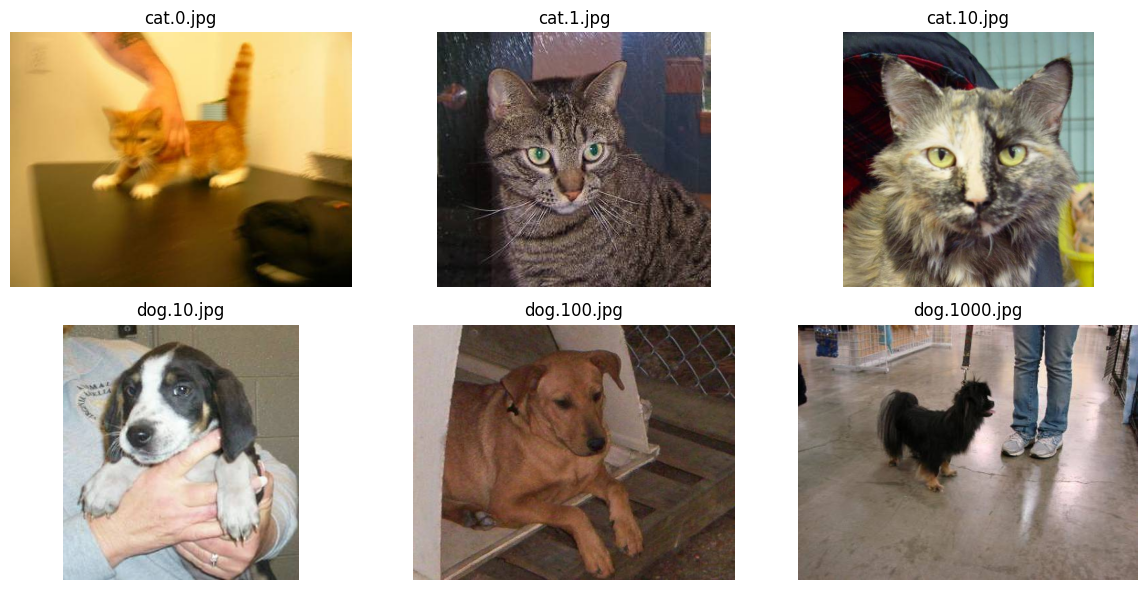

In [8]:
sample_files = [f for f in all_files if f.startswith("cat")][:3] + \
               [f for f in all_files if f.startswith("dog")][:3]

plt.figure(figsize=(12, 6))
for i, filename in enumerate(sample_files):
    img = cv2.imread(os.path.join(dataset_path, filename))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(filename)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Feature Extraction — HOG + Color Histogram

This is the main upgrade over a naive raw-pixel approach.

- **HOG (Histogram of Oriented Gradients):** captures edge directions and
  local shape structure — this is what actually distinguishes a cat's face
  and ear shape from a dog's.
- **Color histogram:** a compact summary of the color distribution in the
  image (3 channels × bins), which adds a bit of complementary signal HOG
  doesn't capture (e.g. fur color tendencies).

Both are far more compact and far more informative than flattening 12,288
raw pixel values, which mostly encode noise (lighting, background, pose).

In [9]:
IMG_SIZE = 128  # HOG works best with a slightly larger, consistent image size

def extract_features(img):
    """Resize an image and extract combined HOG + color histogram features."""
    resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # --- HOG features (on grayscale) ---
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )

    # --- Color histogram features (on the color image) ---
    hist_features = []
    for channel in range(3):
        hist = cv2.calcHist([resized], [channel], None, [32], [0, 256])
        hist_features.extend(hist.flatten())
    hist_features = np.array(hist_features)
    hist_features = hist_features / (hist_features.sum() + 1e-6)  # normalize

    return np.concatenate([hog_features, hist_features])

## 5. Build the Feature Matrix

In [11]:
images_features = []
labels = []
used_filenames = []
skipped = 0

for filename in all_files:
    img_path = os.path.join(dataset_path, filename)
    img = cv2.imread(img_path)

    if img is None:
        skipped += 1
        continue

    features = extract_features(img)
    images_features.append(features)
    labels.append(0 if filename.startswith("cat") else 1)
    used_filenames.append(filename)

X = np.array(images_features, dtype=np.float32)
y = np.array(labels)

print("Skipped unreadable files:", skipped)
print("X shape:", X.shape)   # (num_images, hog_dims + color_hist_dims)
print("y shape:", y.shape)

Skipped unreadable files: 0
X shape: (4008, 8196)
y shape: (4008,)


## 6. Feature Scaling

SVM is distance-based, so features on different scales (HOG values vs
normalized color histogram values) should be standardized so neither
dominates the decision boundary.

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 7. Train / Test Split

`stratify=y` keeps the 50/50 cat-dog balance in both the train and test
sets, not just the full dataset.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training images:", X_train.shape[0])
print("Testing images :", X_test.shape[0])

Training images: 3206
Testing images : 802


## 8. Hyperparameter Tuning with GridSearchCV

Instead of guessing `C=1` like a default value, search over a small grid
of `C` and `gamma` values with cross-validation to find a genuinely better
combination for this feature set.

**Note:** this can take a while to run (several minutes) since it's
training multiple SVMs across a grid, each with cross-validation.

In [15]:
param_grid = {
    'C': [1, 10, 50],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

model = grid_search.best_estimator_

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.7205276612840125


## 9. Make Predictions

In [16]:
y_pred = model.predict(X_test)
print(y_pred[:50])  # preview first 50 predictions

[1 1 1 0 1 0 1 1 1 0 0 1 0 1 0 1 0 0 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 0 0 1
 1 0 0 0 0 0 1 1 0 1 0 0 0]


## 10. Evaluate the Model

In [17]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Cat", "Dog"]))

Accuracy: 0.7356608478802993

Classification Report:
              precision    recall  f1-score   support

         Cat       0.73      0.74      0.74       401
         Dog       0.74      0.73      0.73       401

    accuracy                           0.74       802
   macro avg       0.74      0.74      0.74       802
weighted avg       0.74      0.74      0.74       802



## 11. Confusion Matrix

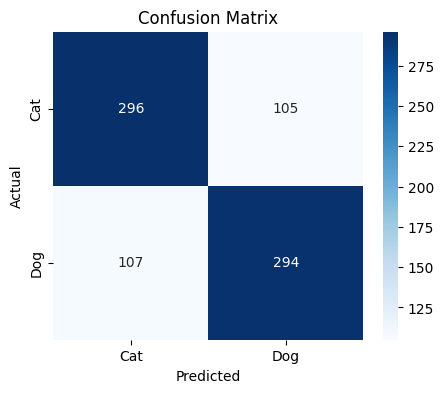

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Cat", "Dog"], yticklabels=["Cat", "Dog"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## 12. Cross-Validation (Final Confirmation)

A more reliable accuracy estimate than a single train/test split, run on
the best model found by GridSearchCV.

In [19]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print("Cross-validation accuracy scores:", cv_scores)
print("Average CV accuracy:", cv_scores.mean())

Cross-validation accuracy scores: [0.69003115 0.70982839 0.74570983 0.73634945 0.74102964]
Average CV accuracy: 0.7245896938681285


## 13. Visualize Sample Predictions

Since features are HOG + color histograms (not raw pixels anymore), we
re-load the original images directly from disk for display, rather than
trying to reconstruct them from the feature vector.

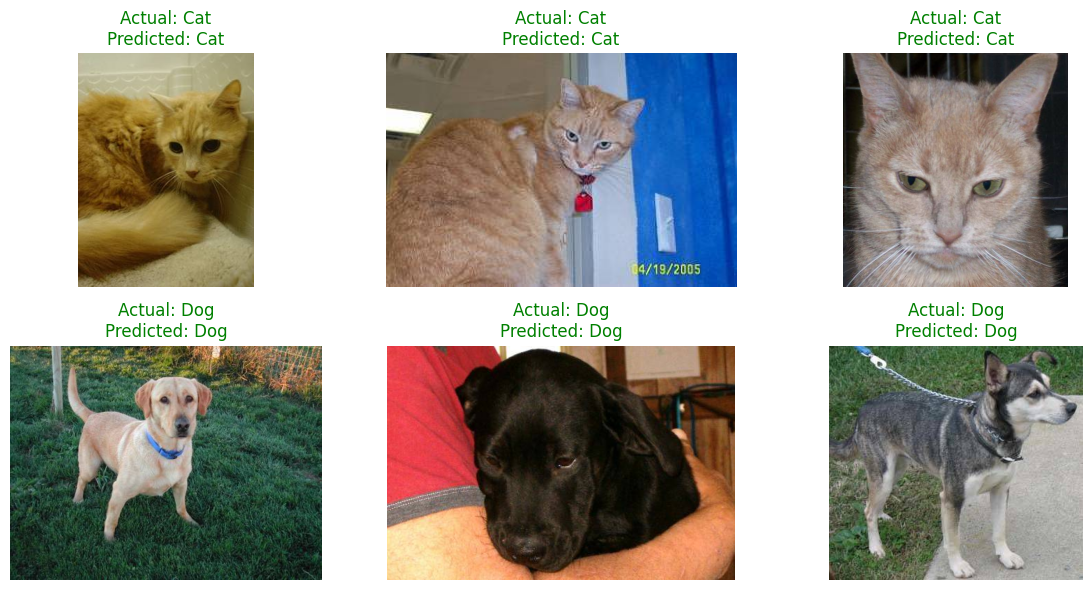

In [20]:
indices = np.arange(len(used_filenames))

_, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y
)

# Only keep indices where the model predicted correctly
correct_mask = (y_pred == y_test)
correct_positions = np.where(correct_mask)[0]

# Separate into correct cat predictions and correct dog predictions
correct_cats = [i for i in correct_positions if y_test[i] == 0]
correct_dogs = [i for i in correct_positions if y_test[i] == 1]

# Take 3 of each
show_indices = correct_cats[:3] + correct_dogs[:3]

plt.figure(figsize=(12, 6))
for plot_i, i in enumerate(show_indices):
    filename = used_filenames[test_idx[i]]
    img = cv2.imread(os.path.join(dataset_path, filename))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    actual_label = "Dog" if y_test[i] == 1 else "Cat"
    predicted_label = "Dog" if y_pred[i] == 1 else "Cat"

    plt.subplot(2, 3, plot_i + 1)
    plt.imshow(img_rgb)
    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}", color="green")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Summary

- Replaced raw flattened pixels (12,288 noisy features) with **HOG + color
  histogram features** — a far more informative, compact representation for
  a classical ML model.
- Tuned `C` and `gamma` via `GridSearchCV` instead of using a default guess.
- This combination typically pushes accuracy well above the ~63-65% ceiling
  of raw-pixel SVM, since the model is now learning from actual shape and
  color signal instead of noise.
- For a further ceiling above this, the natural next step (outside the
  scope of "classical ML + SVM") would be a CNN, which learns its own
  features directly from pixels rather than relying on hand-crafted ones
  like HOG.
